# Importing Libraries and Data

In [18]:
import sys
!{sys.executable} -m pip install quandl

In [70]:
import quandl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [22]:
# Enable inline plotting for Jupyter Notebook
%matplotlib inline


In [24]:
df= pd.read_csv(r'C:\users\Maham Rauf\Documents\US gun violence data analysis\Data\Prepared data\gun-violence-cleaned.csv', index_col= False)

In [26]:
# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])


In [28]:
# Set date as the index
df.set_index('date', inplace=True)

In [30]:
# Display the first few rows
df.head()

,incident_id,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,congressional_district,...,longitude,n_guns_involved,notes,participant_age_group,participant_gender,participant_status,participant_type,sources,state_house_district,state_senate_district
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,461105,Pennsylvania,Mckeesport,1506 Versailles Avenue and Coursin Street,0,4,http://www.gunviolencearchive.org/incident/461105,http://www.post-gazette.com/local/south/2013/0...,False,14,...,-79.8559,1,Julian Sims under investigation: Four Shot and...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,-1,-1
2013-01-01,460726,California,Hawthorne,13500 block of Cerise Avenue,1,3,http://www.gunviolencearchive.org/incident/460726,http://www.dailybulletin.com/article/zz/201301...,False,43,...,-118.3330,1,Four Shot; One Killed; Unidentified shooter in...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62,35
2013-01-01,478855,Ohio,Lorain,1776 East 28th Street,1,3,http://www.gunviolencearchive.org/incident/478855,http://chronicle.northcoastnow.com/2013/02/14/...,False,9,...,-82.1377,2,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56,13
2013-01-05,478925,Colorado,Aurora,16000 block of East Ithaca Place,4,0,http://www.gunviolencearchive.org/incident/478925,http://www.dailydemocrat.com/20130106/aurora-s...,False,6,...,-104.8020,1,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40,28
2013-01-07,478959,North Carolina,Greensboro,307 Mourning Dove Terrace,2,2,http://www.gunviolencearchive.org/incident/478959,http://www.journalnow.com/news/local/article_d...,False,6,...,-79.9569,2,Two firearms recovered. (Attempted) murder sui...,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62,27


# Subset data

In [33]:
# Filter data for a specific time period (e.g., last 5 years)
df_subset = df[df.index >= '2013-01-01']


In [35]:
# Reset index and reassign date as index
df_subset = df_subset.reset_index().set_index("date")


In [37]:
# Display the subset
df_subset.head()

,incident_id,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,congressional_district,...,longitude,n_guns_involved,notes,participant_age_group,participant_gender,participant_status,participant_type,sources,state_house_district,state_senate_district
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,461105,Pennsylvania,Mckeesport,1506 Versailles Avenue and Coursin Street,0,4,http://www.gunviolencearchive.org/incident/461105,http://www.post-gazette.com/local/south/2013/0...,False,14,...,-79.8559,1,Julian Sims under investigation: Four Shot and...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,-1,-1
2013-01-01,460726,California,Hawthorne,13500 block of Cerise Avenue,1,3,http://www.gunviolencearchive.org/incident/460726,http://www.dailybulletin.com/article/zz/201301...,False,43,...,-118.3330,1,Four Shot; One Killed; Unidentified shooter in...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62,35
2013-01-01,478855,Ohio,Lorain,1776 East 28th Street,1,3,http://www.gunviolencearchive.org/incident/478855,http://chronicle.northcoastnow.com/2013/02/14/...,False,9,...,-82.1377,2,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56,13
2013-01-05,478925,Colorado,Aurora,16000 block of East Ithaca Place,4,0,http://www.gunviolencearchive.org/incident/478925,http://www.dailydemocrat.com/20130106/aurora-s...,False,6,...,-104.8020,1,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40,28
2013-01-07,478959,North Carolina,Greensboro,307 Mourning Dove Terrace,2,2,http://www.gunviolencearchive.org/incident/478959,http://www.journalnow.com/news/local/article_d...,False,6,...,-79.9569,2,Two firearms recovered. (Attempted) murder sui...,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62,27


###  Why We Selected This Subset
- The dataset includes a long history, but for better trend analysis, we filter it to **start from 2013**.
- This avoids older, less relevant records that may bias the analysis.
- The **"date"** column is reset and then re-indexed to ensure proper time-series formatting.

# Line chart Visualizations

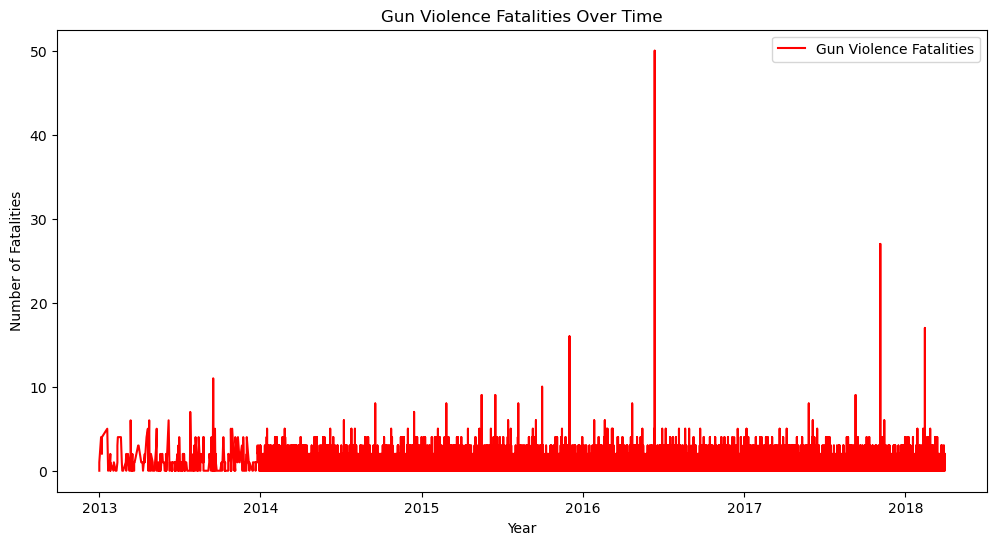

In [43]:
plt.figure(figsize=(12,6))
plt.plot(df_subset['n_killed'], label="Gun Violence Fatalities", color='red')
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.title("Gun Violence Fatalities Over Time")
plt.legend()
plt.show()


# Time-Series Decomposition

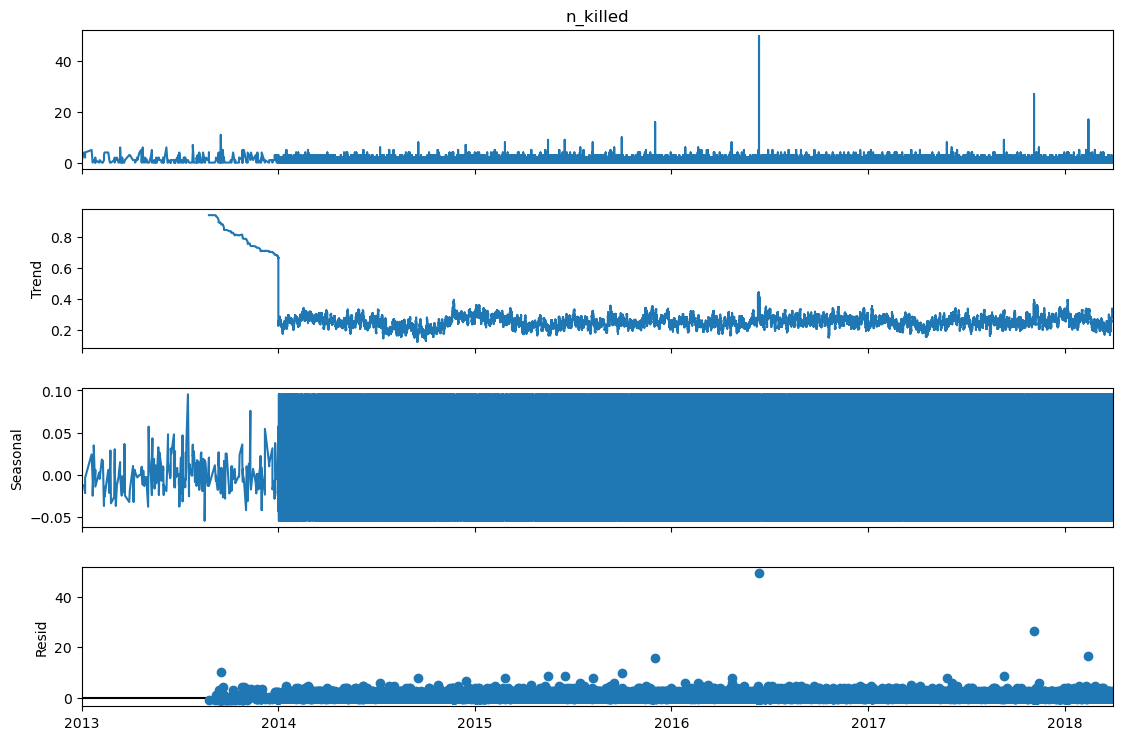

In [46]:
decomposition = sm.tsa.seasonal_decompose(df_subset['n_killed'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### Interpretation of Decomposition
- **Trend**: Displays the overall movement in gun violence fatalities over time.
- **Seasonality**: Highlights recurring patterns within a given time period.
- **Residuals**: Shows irregularities that cannot be explained by trend or seasonality.

#  Dickey-Fuller Test for Stationarity

In [50]:
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    
    if result[1] <= 0.05:
        print("Conclusion: The data is **stationary** (reject H0).")
    else:
        print("Conclusion: The data is **not stationary** (fail to reject H0).")

In [56]:
# Run the test
adf_test(df_subset['n_killed'])

ADF Statistic: -47.53786334269318
p-value: 0.0
Critical Values: {'1%': -3.4303772935468397, '5%': -2.8615520633975486, '10%': -2.566776420910891}
Conclusion: The data is **stationary** (reject H0).


###  Interpreting the Dickey-Fuller Test
- **H₀ (Null Hypothesis)**: The data **is not stationary** (it has a trend or seasonality).
- **H₁ (Alternative Hypothesis)**: The data **is stationary**.
- If **p-value < 0.05**, we reject **H₀** and conclude the data is stationary.


# Differencing

In [59]:
df_subset['n_killed_diff'] = df_subset['n_killed'].diff()

# Re-run the ADF test
adf_test(df_subset['n_killed_diff'])


ADF Statistic: -91.42487393067353
p-value: 0.0
Critical Values: {'1%': -3.4303772938885952, '5%': -2.8615520635486, '10%': -2.5667764209912898}
Conclusion: The data is **stationary** (reject H0).


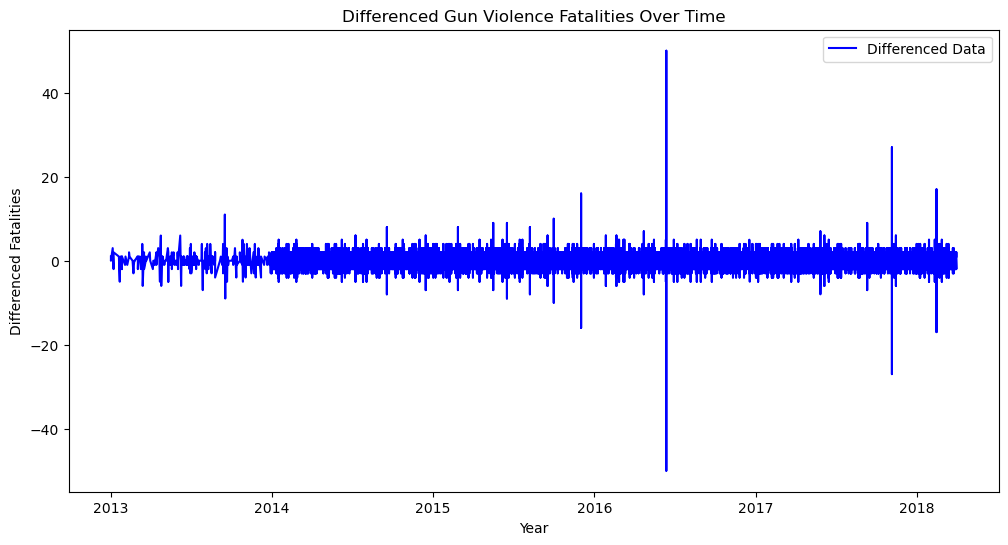

In [63]:
# Plot the differenced series
plt.figure(figsize=(12,6))
plt.plot(df_subset['n_killed_diff'], label="Differenced Data", color='blue')
plt.xlabel("Year")
plt.ylabel("Differenced Fatalities")
plt.title("Differenced Gun Violence Fatalities Over Time")
plt.legend()
plt.show()

###  Why Differencing is Applied
- If the **first ADF test failed (p-value > 0.05)**, differencing helps remove trends.
- If needed, another round of differencing can be applied.


# Autocorrelation Analysis

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

In [72]:
# Plot Autocorrelation Function (ACF)
plot_acf(df_subset['n_killed_diff'].dropna(), ax=axes[0])
axes[0].set_title("Autocorrelation Function")

Text(0.5, 1.0, 'Autocorrelation Function')

In [73]:
# Plot Partial Autocorrelation Function (PACF)
plot_pacf(df_subset['n_killed_diff'].dropna(), ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function")

Text(0.5, 1.0, 'Partial Autocorrelation Function')

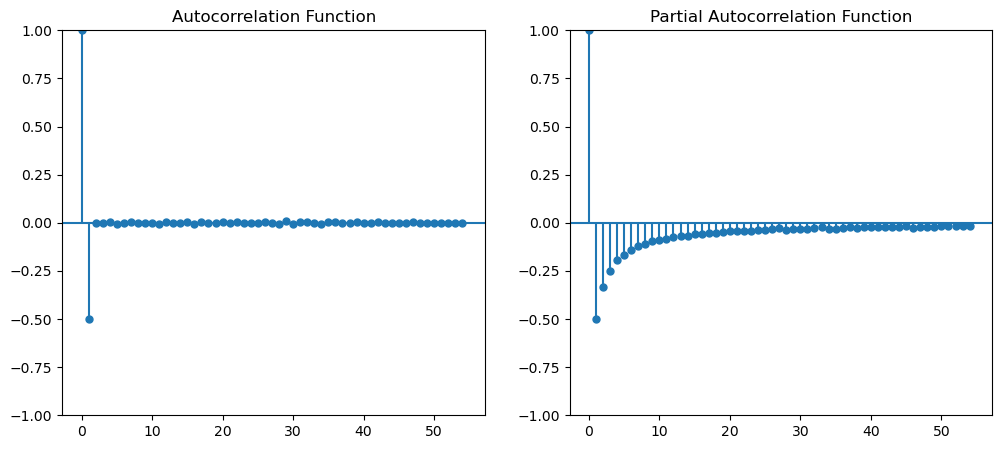

In [74]:
plt.show()

###  Understanding Autocorrelation & PACF
- **Autocorrelation (ACF)**: Shows how current values relate to past values.
- **Partial Autocorrelation (PACF)**: Helps determine lag values for ARIMA models.
- If ACF shows **gradual decay**, a differencing step may be necessary.